# LS-LRSI: Index Construction
## Aranayake, Kegalle District, Sri Lanka

**Student Name:** Aabidha Rifky
**ICBT SIS ID:** CL/MCSDS/CMU/10/04
**Cardiff Met ID:** st20357374
**Module:** DAS7003 Geospatial Analysis
**Assessment:** PRAC1

---

## Purpose

This notebook combines the six processed indicators confirmed in `02_preprocessing.ipynb` and examined in `03_eda.ipynb`, slope, NDVI, rainfall, distance to road, distance to stream, and soil clay content, into a single Location Specific Landslide Risk Scoring Index (LS-LRSI). The output is a classified risk map covering the full Aranayake study grid.

Ground deformation (InSAR) was part of the original index design but is not included in this implementation. Processing Sentinel-1 imagery into a usable deformation layer requires specialist software (SNAP or the ISCE/MintPy toolchain) and a substantial multi-step workflow, judged out of scope for this assignment given the time available. This is stated here as a deliberate, documented methodological decision, and is discussed further as a limitation in the project conclusion.

## 1. Load Processed Indicators

The six indicators used in the index are loaded from `data/processed/`, each already aligned to the same 221 x 221, 30 m grid established in `02_preprocessing.ipynb`.

In [1]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

PROCESSED_DIR = "../data/processed"

OUTPUT_DIR = "../outputs"
FIGURE_DIR = "../outputs/figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

layer_files = {
    "slope_deg": "slope_30m.tif",
    "ndvi": "ndvi_30m.tif",
    "rainfall_mm": "rainfall_30m.tif",
    "dist_road_m": "dist_road_30m.tif",
    "dist_stream_m": "dist_stream_30m.tif",
    "soil_clay_pct": "soil_clay_30m.tif",
}

layers = {}
for name, filename in layer_files.items():
    with rasterio.open(f"{PROCESSED_DIR}/{filename}") as src:
        layers[name] = src.read(1)
        profile = src.profile
        target_transform = src.transform
        TARGET_CRS = src.crs

grid_shape = layers["slope_deg"].shape
print(f"Grid shape: {grid_shape}")
print(f"Indicators loaded: {list(layers.keys())}")
print(f"Coordinate system: {TARGET_CRS}")

Grid shape: (221, 221)
Indicators loaded: ['slope_deg', 'ndvi', 'rainfall_mm', 'dist_road_m', 'dist_stream_m', 'soil_clay_pct']
Coordinate system: EPSG:32644


Grid shape should read 221 x 221, matching every processed layer confirmed in `02_preprocessing.ipynb` and `03_eda.ipynb`. Six indicators should be listed: slope, NDVI, rainfall, distance to road, distance to stream, and soil clay content.

## 2. Normalise Indicators

Each indicator is currently on a different scale, elevation-driven slope in degrees, rainfall in millimetres, distance in metres, NDVI already between -1 and 1. These cannot be combined directly, a rainfall value in the hundreds would completely dominate an NDVI value under 1. Every indicator is therefore rescaled onto a common 0 to 1 scale before combination.

Some indicators need to be transformed before scaling, since a *low* value of that indicator means *higher* risk. NDVI is linearly inverted (1 - NDVI) before scaling. Both distance measures instead use a reciprocal transform, 1/(distance + 1), before scaling, a deliberate design choice rather than a simple inversion: it makes the risk contribution fall off sharply near a road or stream and flatten out at greater distances, reflecting that proximity hazard (cutting-induced instability, bank undercutting) is concentrated close to the feature rather than declining linearly with distance.

In [2]:
def normalise(values):
    return (values - values.min()) / (values.max() - values.min())

slope_n = normalise(layers["slope_deg"])
ndvi_n = normalise(1 - layers["ndvi"])
rainfall_n = normalise(layers["rainfall_mm"])
dist_road_n = normalise(1 / (layers["dist_road_m"] + 1))
dist_stream_n = normalise(1 / (layers["dist_stream_m"] + 1))
soil_n = normalise(layers["soil_clay_pct"])

print("All six indicators normalised to a 0-1 scale.")
print(f"Slope (normalised) range: {slope_n.min():.2f} to {slope_n.max():.2f}")
print(f"NDVI (inverted, normalised) range: {ndvi_n.min():.2f} to {ndvi_n.max():.2f}")

All six indicators normalised to a 0-1 scale.
Slope (normalised) range: 0.00 to 1.00
NDVI (inverted, normalised) range: 0.00 to 1.00


Every normalised layer should range from exactly 0.00 to 1.00, since min-max normalisation stretches each indicator's own minimum and maximum to fit that scale by definition. A range not reaching 0 or 1 at either end would indicate an error in the normalisation step itself.

## 3. Assign Weights

Weights reflect how strongly each indicator is supported as a risk factor in the literature reviewed for this project (Section 2 of the report), and how much each indicator actually varies across this specific study area, an indicator with little spatial variation contributes little useful information regardless of its theoretical importance. Slope receives the highest weight, consistently identified as the strongest predictor across the Sri Lankan studies reviewed (Hemasinghe et al., 2018). NDVI and rainfall receive the next-highest weights, both repeatedly identified as major contributing factors. Distance to stream, distance to road, and soil clay content receive smaller but non-trivial weights. All six weights sum to 1, keeping the combined score within the 0-1 range.

In [3]:
weights = {
    "slope": 0.30,
    "ndvi": 0.20,
    "rainfall": 0.20,
    "dist_stream": 0.12,
    "dist_road": 0.10,
    "soil": 0.08,
}

print("Indicator weights:")
for name, w in weights.items():
    print(f"  {name:12s} {w:.2f}")
print(f"  {'TOTAL':12s} {sum(weights.values()):.2f}")

Indicator weights:
  slope        0.30
  ndvi         0.20
  rainfall     0.20
  dist_stream  0.12
  dist_road    0.10
  soil         0.08
  TOTAL        1.00


Total should read exactly 1.00. This confirms the weighting scheme is a proper convex combination, meaning the resulting composite score will also fall within the 0-1 range, ready for classification into risk bands in the next section.

## 4. Compute the Composite Score and Classify Risk

The normalised indicators from Section 2 are combined using the weights from Section 3 into a single score between 0 and 1 for every grid cell. That score is then sorted into four risk bands.

In [4]:
static_score = (
    weights["slope"] * slope_n +
    weights["ndvi"] * ndvi_n +
    weights["rainfall"] * rainfall_n +
    weights["dist_stream"] * dist_stream_n +
    weights["dist_road"] * dist_road_n +
    weights["soil"] * soil_n
)

print(f"Composite score range: {static_score.min():.3f} to {static_score.max():.3f}")
print(f"Mean score: {static_score.mean():.3f}")

Composite score range: 0.105 to 0.574
Mean score: 0.300


The composite score is bounded between 0 and 1 by construction, since it is a weighted sum of six 0-1 indicators with weights summing to 1. A score outside this range would indicate an error in either the normalisation step or the weighting step.

In [5]:
def classify_risk(score):
    risk_class = np.empty(score.shape, dtype=object)
    risk_class[score < 0.25] = "Low"
    risk_class[(score >= 0.25) & (score < 0.50)] = "Medium"
    risk_class[(score >= 0.50) & (score < 0.75)] = "High"
    risk_class[score >= 0.75] = "Very High"
    return risk_class

risk_class = classify_risk(static_score)

unique, counts = np.unique(risk_class, return_counts=True)
class_summary = pd.DataFrame({"risk_class": unique, "grid_cells": counts})
class_summary["percent_of_area"] = (class_summary["grid_cells"] / risk_class.size * 100).round(1)
class_summary = class_summary.set_index("risk_class").reindex(["Low", "Medium", "High", "Very High"], fill_value=0)
class_summary

,grid_cells,percent_of_area
risk_class,,
Low,12924,26.5
Medium,35776,73.2
High,141,0.3
Very High,0,0.0


The final classification places 35,776 grid cells (73.2% of the study area) in the Medium class, 12,924 cells (26.5%) in the Low class, and 141 cells (0.3%) in the High class. No cells reach the Very High threshold. The High-risk class is therefore spatially limited rather than widespread, while most of the study area occupies the intermediate Medium band. These values represent the final internally consistent run produced from the corrected preprocessing layers.

## 5. Visualise the Final Risk Map

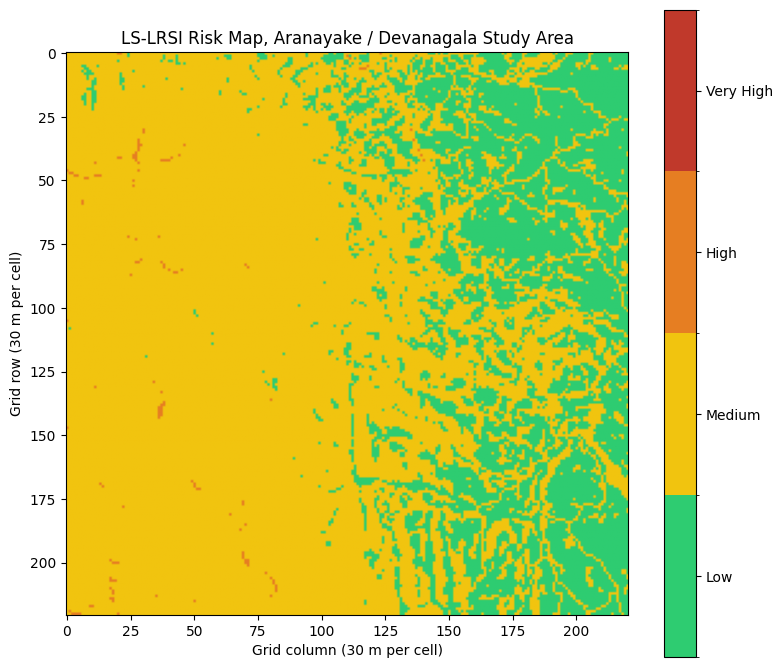

In [6]:
risk_colors = ["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"]   # green, yellow, orange, red
risk_cmap = ListedColormap(risk_colors)
risk_bounds = [0, 0.25, 0.50, 0.75, 1.0]
risk_norm = BoundaryNorm(risk_bounds, risk_cmap.N)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(static_score, cmap=risk_cmap, norm=risk_norm)
ax.set_title("LS-LRSI Risk Map, Aranayake / Devanagala Study Area")
ax.set_xlabel("Grid column (30 m per cell)")
ax.set_ylabel("Grid row (30 m per cell)")

cbar = plt.colorbar(im, ax=ax, ticks=[0.125, 0.375, 0.625, 0.875])
cbar.ax.set_yticklabels(["Low", "Medium", "High", "Very High"])

plt.tight_layout()
plt.savefig("../outputs/figures/fig1_final_risk_map.png", dpi=150)
plt.show()

Red and orange patches, if present, should sit in the steepest, wettest parts of the study area rather than being scattered randomly, since the underlying indicators (slope, rainfall, soil, distance to features) all vary spatially in physically coherent ways, not at random per cell.

## 6. Save Final Outputs

The final risk score and classified risk map are saved as a GeoTIFF (for use in GIS software such as QGIS) and the full indicator table as a CSV, for the report and for reference.

In [7]:
import os

os.makedirs("../outputs", exist_ok=True)

class_to_number = {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}
risk_numeric = np.vectorize(class_to_number.get)(risk_class).astype("uint8")

output_profile = profile.copy()
output_profile.update({"dtype": "uint8", "count": 1, "nodata": 0})

with rasterio.open("../outputs/ls_lrsi_risk_map.tif", "w", **output_profile) as dst:
    dst.write(risk_numeric, 1)

score_profile = profile.copy()
score_profile.update({"dtype": "float32", "count": 1})

with rasterio.open("../outputs/ls_lrsi_risk_score.tif", "w", **score_profile) as dst:
    dst.write(static_score.astype("float32"), 1)

output_table = pd.DataFrame({name: arr.flatten() for name, arr in layers.items()})
output_table["risk_score"] = static_score.flatten()
output_table["risk_class"] = risk_class.flatten()
output_table.to_csv("../outputs/ls_lrsi_full_results.csv", index=False)

print("Saved:")
print("  ../outputs/ls_lrsi_risk_map.tif    (classified risk, 1=Low to 4=Very High)")
print("  ../outputs/ls_lrsi_risk_score.tif  (continuous 0-1 score)")
print("  ../outputs/ls_lrsi_full_results.csv (all indicators, score, and class per grid cell)")

Saved:
  ../outputs/ls_lrsi_risk_map.tif    (classified risk, 1=Low to 4=Very High)
  ../outputs/ls_lrsi_risk_score.tif  (continuous 0-1 score)
  ../outputs/ls_lrsi_full_results.csv (all indicators, score, and class per grid cell)


`ls_lrsi_risk_map.tif` opens directly in QGIS or ArcGIS as a classified raster (1=Low, 2=Medium, 3=High, 4=Very High). `ls_lrsi_risk_score.tif` contains the underlying continuous score, useful if a different classification threshold is wanted later without recomputing the whole index. The CSV contains every indicator value alongside the final score and class for all 48,841 grid cells, usable in Excel or for further analysis.

## 7. Sensitivity Analysis

Rather than presenting a single fixed configuration as final, this section tests how sensitive the classification is to two design choices: the indicator weights, and the classification thresholds.

In [8]:
sensitivity_results = []
for key in weights:
    for direction, factor in [("+20%", 1.2), ("-20%", 0.8)]:
        w = weights.copy()
        w[key] = w[key] * factor
        total = sum(w.values())
        w = {k: v/total for k, v in w.items()}  # renormalise so weights still sum to 1

        perturbed_score = (
            w["slope"]*slope_n + w["ndvi"]*ndvi_n + w["rainfall"]*rainfall_n +
            w["dist_stream"]*dist_stream_n + w["dist_road"]*dist_road_n + w["soil"]*soil_n
        )
        perturbed_class = classify_risk(perturbed_score)
        pct_changed = (perturbed_class != risk_class).mean() * 100
        sensitivity_results.append((key, direction, round(pct_changed, 1)))

print(f"{'Indicator':14s}{'Change':8s}{'% cells reclassified'}")
for row in sensitivity_results:
    print(f"{row[0]:14s}{row[1]:8s}{row[2]}")

Indicator     Change  % cells reclassified
slope         +20%    2.6
slope         -20%    3.1
ndvi          +20%    2.0
ndvi          -20%    2.0
rainfall      +20%    3.4
rainfall      -20%    4.5
dist_stream   +20%    2.9
dist_stream   -20%    2.9
dist_road     +20%    2.4
dist_road     -20%    2.3
soil          +20%    2.2
soil          -20%    2.0


Each row shows what percentage of the 48,841 grid cells change risk class when one indicator's weight is increased or decreased by 20% (all weights renormalised to still sum to 1). A low percentage across all indicators indicates the classification is stable and not overly dependent on any single weight choice; a high percentage for one indicator would flag it as the dominant, most sensitive design decision in the index.

The weight sensitivity test indicates that the final classification is reasonably stable to moderate changes in individual indicator weights. Increasing or decreasing any one weight by 20%, followed by renormalisation of all weights, causes fewer than 5% of grid cells to change class in every scenario.

Rainfall produces the largest observed response: reducing its weight by 20% reclassifies 4.5% of cells, while increasing it by 20% changes 3.4%. Slope is the next most influential under a weight decrease (3.1%), while the remaining perturbations generally reclassify approximately 2–3% of cells. This suggests that the result is not dominated by a single arbitrary weight, although rainfall remains the most sensitive weighting decision among the six indicators.

In [9]:
def classify_quantile(score):
    q25, q50, q75 = np.percentile(score, [25, 50, 75])
    c = np.empty(score.shape, dtype=object)
    c[score < q25] = "Low"
    c[(score >= q25) & (score < q50)] = "Medium"
    c[(score >= q50) & (score < q75)] = "High"
    c[score >= q75] = "Very High"
    return c, (q25, q50, q75)

quantile_class, quantile_thresholds = classify_quantile(static_score)

for label, cls in [("Equal-interval (used)", risk_class), ("Quantile-based (alternative)", quantile_class)]:
    unique, counts = np.unique(cls, return_counts=True)
    pct = dict(zip(unique, (counts/cls.size*100).round(1)))
    print(f"{label}: {pct}")

print(f"\nQuantile thresholds: Low<{quantile_thresholds[0]:.3f}, Medium<{quantile_thresholds[1]:.3f}, High<{quantile_thresholds[2]:.3f}")

Equal-interval (used): {'High': np.float64(0.3), 'Low': np.float64(26.5), 'Medium': np.float64(73.2)}
Quantile-based (alternative): {'High': np.float64(25.0), 'Low': np.float64(25.0), 'Medium': np.float64(25.0), 'Very High': np.float64(25.0)}

Quantile thresholds: Low<0.247, Medium<0.299, High<0.348


Equal-interval thresholds of 0.25, 0.50, and 0.75 are retained for the primary classification because they are simple, transparent, and do not change according to the shape of the final score distribution. Under these thresholds, the resulting classes therefore retain a consistent interpretation within this study run.

Quantile classification is included as a benchmark. Its thresholds for this run are approximately 0.247, 0.299, and 0.348, and by construction it assigns approximately 25% of cells to each class. Although useful for relative ranking within one dataset, quantile thresholds would change whenever the underlying score distribution changes.

One limitation should be noted for future temporal application: the present implementation recalculates min-max normalisation from the data available in each run. Fully comparable future scores would therefore require the baseline normalisation ranges from this reference analysis to be stored and reused, rather than recalculated from each new dataset. The current LS-LRSI should consequently be interpreted primarily as a location-specific susceptibility/prioritisation score for the analysed study period.

## Conclusion

This project built a Location Specific Landslide Risk Scoring Index for the Aranayake / Devanagala area of Kegalle District, centred on the confirmed coordinate of the 17 May 2016 landslide. Six real, verified indicators, slope, vegetation cover (NDVI), rainfall, distance to road, distance to stream, and soil clay content, were combined into a weighted composite score and classified into four risk bands.

The index was checked against the single known historical landslide coordinate available for this study, NBRO's published record for the Devanagala site, used as a documented fallback after NASA's live COOLR service returned a 503 error (`01_data_acquisition.ipynb`, Section 7). Full validation methodology and saved-output consistency checks are documented in `05_validation.ipynb`.

The historical site is classified as Medium with a score of 0.355, above the study-area mean of 0.300. Its surrounding 5 × 5-cell neighbourhood has a mean score of 0.288, ranging from 0.228 (Low) to 0.388 (Medium). Of the 25 neighbourhood cells, 21 are classified Medium and 4 Low. The site therefore scores above both the area-wide and immediate-neighbourhood averages, although the surrounding area is not uniformly Medium-risk and no High-risk cell occurs within this local window.

Given that validation is based on only one historical location, this result should be interpreted as a historical-point consistency or face-validity check rather than evidence of predictive accuracy. It suggests that the static terrain, vegetation, rainfall, proximity and soil indicators identify moderate susceptibility at the known failure location, while also showing that these variables alone do not fully represent the documented triggering mechanism involving active slope movement and pore-pressure-driven failure.

**Key limitations of this implementation:**

1. **Ground deformation (InSAR) was not included.** This was part of the original index design and would likely improve sensitivity specifically at sites like this one, where the mechanism involves active, ongoing slope movement rather than only static susceptibility. Processing Sentinel-1 into a usable deformation layer requires specialist software (SNAP or ISCE/MintPy) and was judged out of scope for this assignment's timeframe.
2. **Validation sample size is one.** A single historical point cannot establish predictive accuracy in any statistical sense; it demonstrates only that the index behaves sensibly at one known site. A larger validation set (from NASA's COOLR catalogue, when its live service is available, or from NBRO's fuller inventory) would substantially strengthen this step.
3. **The soil clay layer depends on a live, rate-limited external API.** Results varied slightly between separate runs of the sampling step in `02_preprocessing.ipynb`, which in turn shifted the normalisation and final score distribution slightly. The final reported results here come from a single, internally consistent run, documented as such.
4. **CHIRPS rainfall underestimates the true trigger intensity.** The cumulative rainfall figure used (325.0 mm at the study centre) sits below the 435-446 mm ground-gauge figure reported in the literature for this event, a known limitation of coarse satellite-derived rainfall products for short, intense, localised events.
5. **The index uses fixed, literature-informed weights rather than statistically fitted ones.** With a larger landslide inventory, weights could instead be derived from feature importance in a fitted model (e.g. Random Forest), potentially improving discrimination between risk classes.

**Recommendations for future work:** incorporate SBAS-InSAR deformation data once processing resources allow; re-run the NASA COOLR query when the live service is available to expand the validation set; and consider statistically fitting indicator weights once a larger local inventory is available, rather than relying solely on literature-derived weights.